In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 🔎 Étape 4 : Analyse Exploratoire des Données (EDA)

Cette étape **clôt le Jalon 1**. L'objectif : explorer et résumer les propriétés statistiques de nos données, les enrichir par **feature engineering**, et dégager les **insights majeurs** qui guideront la modélisation.

**Donnée d'entrée :** `data/processed/matches_clean.csv` — les 30 511 matchs nettoyés (depuis 1992), classements FIFA inclus.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src import data_clean as dc

print("Librairies importées pour l'EDA !")

Librairies importées pour l'EDA !


### 2. Chargement des données nettoyées

On charge le jeu de données nettoyé issu de l'étape 2 (Data Wrangling).

In [3]:
df = pd.read_csv('../data/processed/matches_clean.csv')
print(f"Dimensions : {df.shape[0]} matchs, {df.shape[1]} colonnes")
df.head()

Dimensions : 30511 matchs, 14 colonnes


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_rank,home_points,away_rank,away_points,shootout_winner
0,1993-01-01,Ghana,Mali,1.0,1.0,Friendly,Libreville,Gabon,True,39.0,34.0,69.0,22.0,Aucun
1,1993-01-02,Gabon,Burkina Faso,1.0,1.0,Friendly,Libreville,Gabon,False,55.0,27.0,97.0,11.0,Aucun
2,1993-01-02,Kuwait,Lebanon,2.0,0.0,Friendly,Kuwait City,Kuwait,False,71.0,21.0,161.0,0.0,Aucun
3,1993-01-03,Burkina Faso,Mali,1.0,0.0,Friendly,Libreville,Gabon,True,97.0,11.0,69.0,22.0,Aucun
4,1993-01-03,Gabon,Ghana,2.0,3.0,Friendly,Libreville,Gabon,False,55.0,27.0,39.0,34.0,Aucun


### 3. Statistiques descriptives

Résumé statistique global des variables numériques, puis une analyse par groupe : les buts marqués selon que le match se joue sur terrain neutre ou non.

In [4]:
# Résumé statistique global des variables numériques.
print("=== Statistiques descriptives ===")
print(df.describe().round(2))

# Buts moyens selon le lieu : met en évidence l'avantage du terrain.
print("\n=== Buts moyens selon le terrain (neutre ou non) ===")
print(df.groupby('neutral')[['home_score', 'away_score']].mean().round(2))

=== Statistiques descriptives ===
       home_score  away_score  home_rank  home_points  away_rank  away_points
count    30511.00    30511.00   30511.00     30511.00   30511.00     30511.00
mean         1.66        1.11      87.15       598.84      90.74       584.69
std          1.71        1.36      60.47       500.46      61.16       492.53
min          0.00        0.00       1.00         0.00       1.00         0.00
25%          0.00        0.00      36.00       141.00      40.00       126.00
50%          1.00        1.00      78.00       505.00      81.00       497.00
75%          2.00        2.00     129.00       979.00     133.00       958.00
max         31.00       21.00     220.00      2164.00     220.00      2164.00

=== Buts moyens selon le terrain (neutre ou non) ===
         home_score  away_score
neutral                        
False          1.70        1.02
True           1.56        1.35


### 4. Ingénierie de variables (Feature Engineering)

On applique `dc.feature_engineering` pour créer les variables dérivées : indicateurs temporels (`year`, `decade`), variables de match (`goal_difference`, `total_goals`), écart de classement FIFA (`rank_difference`) et la **variable cible** `result` (victoire domicile / nul / victoire extérieur).

In [5]:
# Création des variables dérivées (cf. src/data_clean.py).
df_feat = dc.feature_engineering(df, 'date')
print("Variables créées :", [c for c in df_feat.columns if c not in df.columns])

# Répartition de la variable cible (résultat du match).
print("\n=== Répartition des résultats (%) ===")
print((df_feat['result'].value_counts(normalize=True) * 100).round(1))
df_feat.head()

Variables créées : ['year', 'month', 'decade', 'goal_difference', 'total_goals', 'result', 'rank_difference']

=== Répartition des résultats (%) ===
result
home_win    48.5
away_win    28.1
draw        23.3
Name: proportion, dtype: float64


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_rank,...,away_rank,away_points,shootout_winner,year,month,decade,goal_difference,total_goals,result,rank_difference
0,1993-01-01,Ghana,Mali,1.0,1.0,Friendly,Libreville,Gabon,True,39.0,...,69.0,22.0,Aucun,1993,1,1990,0.0,2.0,draw,30.0
1,1993-01-02,Gabon,Burkina Faso,1.0,1.0,Friendly,Libreville,Gabon,False,55.0,...,97.0,11.0,Aucun,1993,1,1990,0.0,2.0,draw,42.0
2,1993-01-02,Kuwait,Lebanon,2.0,0.0,Friendly,Kuwait City,Kuwait,False,71.0,...,161.0,0.0,Aucun,1993,1,1990,2.0,2.0,home_win,90.0
3,1993-01-03,Burkina Faso,Mali,1.0,0.0,Friendly,Libreville,Gabon,True,97.0,...,69.0,22.0,Aucun,1993,1,1990,1.0,1.0,home_win,-28.0
4,1993-01-03,Gabon,Ghana,2.0,3.0,Friendly,Libreville,Gabon,False,55.0,...,39.0,34.0,Aucun,1993,1,1990,-1.0,5.0,away_win,-16.0


### 5. Analyse des corrélations

On mesure les liens entre variables numériques avec deux coefficients : **Pearson** (relations linéaires) et **Spearman** (relations monotones, plus robuste aux valeurs extrêmes). Le point d'intérêt : l'écart de classement FIFA (`rank_difference`).

In [6]:
# Variables numériques retenues pour l'analyse des corrélations.
cols_num = ['home_score', 'away_score', 'goal_difference', 'total_goals',
            'home_rank', 'away_rank', 'rank_difference', 'year']

print("=== Corrélation de Pearson (relations linéaires) ===")
print(df_feat[cols_num].corr(method='pearson').round(2))

print("\n=== Corrélation de Spearman (relations monotones) ===")
print(df_feat[cols_num].corr(method='spearman').round(2))

=== Corrélation de Pearson (relations linéaires) ===
                 home_score  away_score  goal_difference  total_goals  \
home_score             1.00       -0.18             0.83         0.74   
away_score            -0.18        1.00            -0.70         0.53   
goal_difference        0.83       -0.70             1.00         0.23   
total_goals            0.74        0.53             0.23         1.00   
home_rank             -0.07        0.23            -0.19         0.10   
away_rank              0.28       -0.08             0.25         0.19   
rank_difference        0.38       -0.33             0.47         0.10   
year                  -0.03        0.00            -0.02        -0.03   

                 home_rank  away_rank  rank_difference  year  
home_score           -0.07       0.28             0.38 -0.03  
away_score            0.23      -0.08            -0.33  0.00  
goal_difference      -0.19       0.25             0.47 -0.02  
total_goals           0.10       0.19

### 6. Matrice de corrélation massive (toutes les variables)

Pour aller plus loin que les seules variables numériques de la section précédente, on encode **toutes** les variables qualitatives (texte, booléen, catégorie) en codes catégoriels (`.astype('category').cat.codes`), puis on calcule la matrice de corrélation complète. La heatmap met ainsi en lumière les éventuelles structures cachées impliquant `home_team`, `away_team`, `tournament`, `city`, `country`, `result`, etc.

⚠️ Les codes catégoriels sont arbitraires (ordre alphabétique des modalités). Les coefficients impliquant ces variables encodées signalent des **dépendances éventuelles**, pas une relation linéaire interprétable — à manipuler avec précaution.

C:\Users\User\AppData\Local\Temp\ipykernel_10124\3612052144.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_a_encoder = df_encoded.select_dtypes(


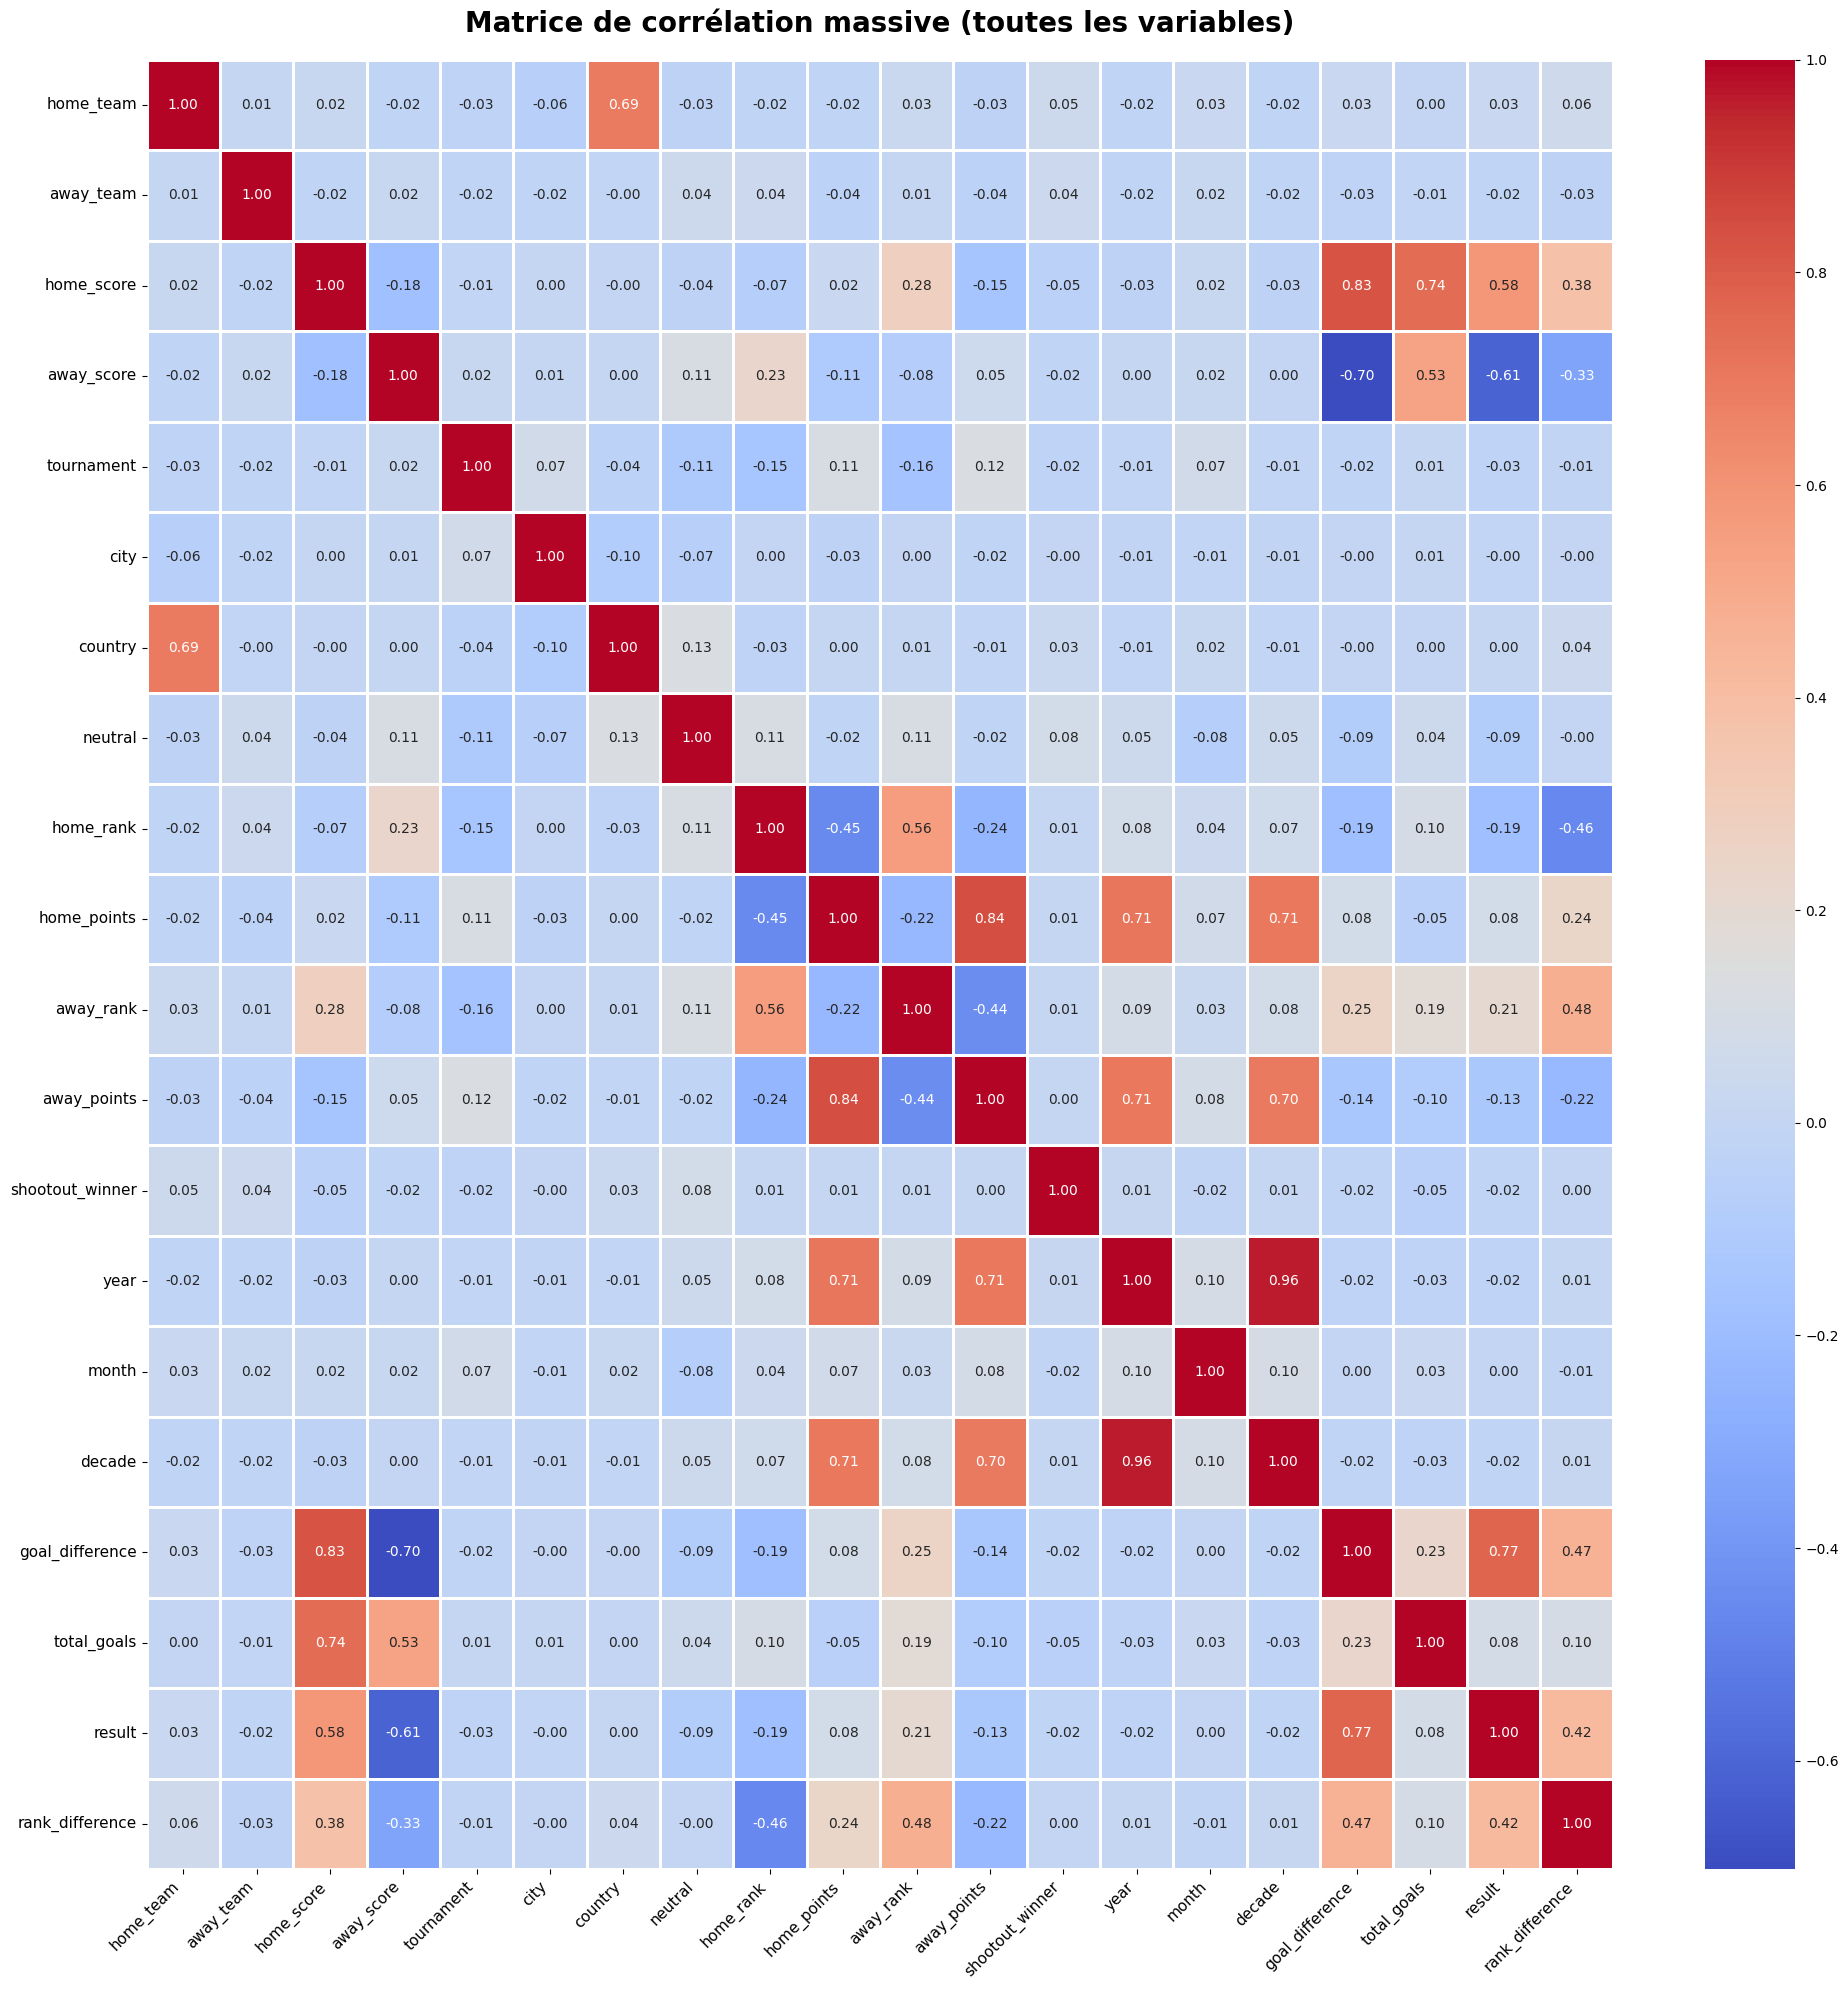

In [7]:
# Encoder toutes les colonnes non-numériques (texte, booléen, catégorie) en codes entiers.
df_encoded = df_feat.copy()
colonnes_a_encoder = df_encoded.select_dtypes(
    include=['object', 'bool', 'category']).columns
for col in colonnes_a_encoder:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Ne conserver que les colonnes numériques (exclut `date`, qui ferait planter le calcul).
df_numerique = df_encoded.select_dtypes(include=[np.number])
corr_massive = df_numerique.corr()

# Heatmap géante : annotations à 2 décimales, palette divergente coolwarm.
fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corr_massive, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=1, ax=ax)
ax.set_title('Matrice de corrélation massive (toutes les variables)',
             fontsize=20, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### 7. Le classement FIFA prédit-il le résultat ?

On croise l'issue du match avec le fait que l'équipe à domicile soit, ou non, mieux classée que son adversaire — un premier aperçu du pouvoir prédictif du classement.

In [8]:
# L'équipe à domicile est-elle mieux classée que son adversaire ?
df_feat['home_mieux_classee'] = df_feat['rank_difference'] > 0

# Issue du match selon ce critère.
taux = (df_feat.groupby('home_mieux_classee')['result']
        .value_counts(normalize=True)
        .mul(100).round(1))
print("Issue du match selon le classement de l'équipe à domicile (%) :")
print(taux)

Issue du match selon le classement de l'équipe à domicile (%) :
home_mieux_classee  result  
False               away_win    43.3
                    home_win    31.1
                    draw        25.6
True                home_win    64.7
                    draw        21.2
                    away_win    14.0
Name: proportion, dtype: float64


### 8. Synthèse — insights majeurs

À l'issue de l'exploration, cinq constats structurent la suite du projet :

1. **Avantage du terrain marqué.** L'équipe à domicile l'emporte dans **48,5 %** des matchs (contre 28,1 % pour l'extérieur et 23,3 % de nuls). Sur terrain neutre, l'écart de buts se réduit nettement (1,56 contre 1,35, contre 1,70 contre 1,02 à domicile).

2. **Le classement FIFA est le signal le plus fort.** Quand l'équipe à domicile est mieux classée que son adversaire, elle gagne **64,7 %** du temps ; quand elle est moins bien classée, ce taux chute à 31,1 % (et elle perd 43,3 % du temps).

3. **L'écart de classement est corrélé à l'écart de buts** (Pearson 0,47, Spearman 0,48) : plus le fossé de classement est grand, plus la victoire tend à être large.

4. **Cible à trois classes déséquilibrée** : les victoires à domicile dominent. Ce déséquilibre devra être pris en compte lors de la modélisation (classe majoritaire).

5. **Pas de tendance temporelle** : les corrélations avec l'année sont quasi nulles (≈ 0) → l'année n'apportera pas d'information prédictive.

➡️ Ces constats orientent le Jalon 2 : le **classement FIFA** et l'**avantage du terrain** seront les variables clés du futur modèle de prédiction.